# Plot2Code Dataset Generation

This notebook generates a dataset of matplotlib plots and their corresponding code for training a vision-language model to generate plotting code from images.

## Setup and Configuration

In [1]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

from pathlib import Path
import shutil
import os

import subprocess

from tqdm import tqdm
import json

import io
import re
import json
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from IPython.display import display, Markdown

## Step 1: Download Matplotlib Examples

Download matplotlib examples repository using sparse checkout to get only the galleries/examples directory.

## Step 2: Filter Example Categories

Keep only specific plot categories and remove others to focus on relevant plot types.

In [1]:
import os, json, subprocess
from pathlib import Path
from tqdm import tqdm

# --- Define paths ---
root_dir = Path().resolve()                         # current working directory
mpl_root = root_dir / "mpl_examples"                # local copy of Matplotlib examples
gallery_dir = root_dir / "plot_gallery_exec"
dataset_file = root_dir / "plot2code_exec.jsonl"

keep = [
    "lines_bars_and_markers",
    "statistics",
    "pie_and_polar_charts",
    "mplot3d",
]

gallery_dir.mkdir(exist_ok=True, parents=True)

print(f"📂 Searching for examples under: {mpl_root}")
print(f"💾 Output dataset: {dataset_file}")

# --- Skip if already exists ---
if dataset_file.exists() and dataset_file.stat().st_size > 1000:
    print(f"✅ Dataset file '{dataset_file.name}' already exists ({dataset_file.stat().st_size/1e6:.1f} MB). Skipping generation.")
    print("🗑️  Delete it if you want to regenerate.")
else:
    dataset = []
    examples = [
        f for f in mpl_root.rglob("*.py")
        if any(k in str(f) for k in keep)
    ]
    print(f"🧮 Found {len(examples)} example scripts to process")

    for f in tqdm(examples, desc="⏳ Generating plots"):
        out_png = gallery_dir / (f.stem + ".png")
        try:
            code = f.read_text()
            # Run each example in an isolated subprocess with Agg backend
            cmd = f"""
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt, numpy as np
exec(open(r'{f}').read(), {{'plt': plt, 'np': np}})
plt.savefig(r'{out_png}', bbox_inches='tight', dpi=150)
"""
            subprocess.run(
                ["python", "-c", cmd],
                check=True,
                timeout=20,
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL,
            )
            if out_png.exists():
                dataset.append({"image": str(out_png), "code": code})
        except Exception as e:
            print(f"⚠️ {f.name}: {e}")

    # --- Save JSONL ---
    with open(dataset_file, "w") as f:
        for d in dataset:
            f.write(json.dumps(d) + "\n")

    print(f"✅ Generated {len(dataset)} valid (image, code) pairs")
    print(f"📁 Saved to {dataset_file.resolve()}")


📂 Searching for examples under: /home/nipun.batra/git/plot2code/mpl_examples
💾 Output dataset: /home/nipun.batra/git/plot2code/plot2code_exec.jsonl
🧮 Found 124 example scripts to process


⏳ Generating plots:  16%|█▌        | 20/124 [00:15<01:21,  1.27it/s]

⚠️ broken_barh.py: Command '['python', '-c', "\nimport matplotlib; matplotlib.use('Agg')\nimport matplotlib.pyplot as plt, numpy as np\nexec(open(r'/home/nipun.batra/git/plot2code/mpl_examples/lines_bars_and_markers/broken_barh.py').read(), {'plt': plt, 'np': np})\nplt.savefig(r'/home/nipun.batra/git/plot2code/plot_gallery_exec/broken_barh.png', bbox_inches='tight', dpi=150)\n"]' returned non-zero exit status 1.


⏳ Generating plots:  24%|██▍       | 30/124 [00:22<01:03,  1.47it/s]

⚠️ hat_graph.py: Command '['python', '-c', "\nimport matplotlib; matplotlib.use('Agg')\nimport matplotlib.pyplot as plt, numpy as np\nexec(open(r'/home/nipun.batra/git/plot2code/mpl_examples/lines_bars_and_markers/hat_graph.py').read(), {'plt': plt, 'np': np})\nplt.savefig(r'/home/nipun.batra/git/plot2code/plot_gallery_exec/hat_graph.png', bbox_inches='tight', dpi=150)\n"]' returned non-zero exit status 1.


...

⚠️ barchart.py: Command '['python', '-c', "\nimport matplotlib; matplotlib.use('Agg')\nimport matplotlib.pyplot as plt, numpy as np\nexec(open(r'/home/nipun.batra/git/plot2code/mpl_examples/lines_bars_and_markers/barchart.py').read(), {'plt': plt, 'np': np})\nplt.savefig(r'/home/nipun.batra/git/plot2code/plot_gallery_exec/barchart.png', bbox_inches='tight', dpi=150)\n"]' returned non-zero exit status 1.


⏳ Generating plots:  82%|████████▏ | 102/124 [01:46<02:24,  6.57s/it]

⚠️ rotate_axes3d_sgskip.py: Command '['python', '-c', "\nimport matplotlib; matplotlib.use('Agg')\nimport matplotlib.pyplot as plt, numpy as np\nexec(open(r'/home/nipun.batra/git/plot2code/mpl_examples/mplot3d/rotate_axes3d_sgskip.py').read(), {'plt': plt, 'np': np})\nplt.savefig(r'/home/nipun.batra/git/plot2code/plot_gallery_exec/rotate_axes3d_sgskip.png', bbox_inches='tight', dpi=150)\n"]' timed out after 19.999991111457348 seconds


⏳ Generating plots: 100%|██████████| 124/124 [02:06<00:00,  1.02s/it]

⚠️ customized_violin.py: Command '['python', '-c', "\nimport matplotlib; matplotlib.use('Agg')\nimport matplotlib.pyplot as plt, numpy as np\nexec(open(r'/home/nipun.batra/git/plot2code/mpl_examples/statistics/customized_violin.py').read(), {'plt': plt, 'np': np})\nplt.savefig(r'/home/nipun.batra/git/plot2code/plot_gallery_exec/customized_violin.png', bbox_inches='tight', dpi=150)\n"]' returned non-zero exit status 1.
✅ Generated 119 valid (image, code) pairs
📁 Saved to /home/nipun.batra/git/plot2code/plot2code_exec.jsonl


## Step 3: Generate Dataset

Execute matplotlib example scripts and save the resulting plots with their source code.

## Step 4: Preview Dataset

Load and display random samples from the generated dataset.

Loaded 119 samples


### `trisurf3d.png`

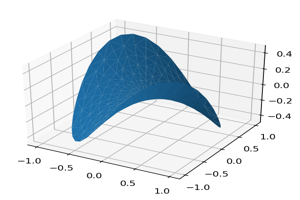

```python
"""
======================
Triangular 3D surfaces
======================

Plot a 3D surface with a triangular mesh.
"""

import matplotlib.pyplot as plt
import numpy as np

n_radii = 8
n_angles = 36

# Make radii and angles spaces (radius r=0 omitted to eliminate duplication).
radii = np.linspace(0.125, 1.0, n_radii)
angles = np.linspace(0, 2*np.pi, n_angles, endpoint=False)[..., np.newaxis]

# Co...
```

### `wire3d.png`

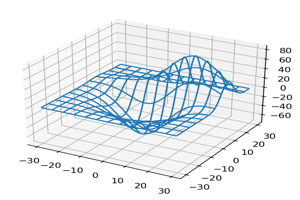

```python
"""
=================
3D wireframe plot
=================

A very basic demonstration of a wireframe plot.
"""

import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import axes3d

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Grab some test data.
X, Y, Z = axes3d.get_test_data(0.05)

# Plot a basic wireframe.
ax.plot_wireframe(X, Y, Z, rstride=10, cstride=10)

plt.show()

# %%
...
```

### `tricontourf3d.png`

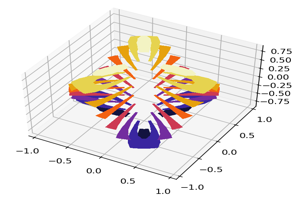

```python
"""
=================================
Triangular 3D filled contour plot
=================================

Filled contour plots of unstructured triangular grids.

The data used is the same as in the second plot of :doc:`trisurf3d_2`.
:doc:`tricontour3d` shows the unfilled version of this example.
"""

import matplotlib.pyplot as plt
import numpy as np

import matplotlib.tri as tri

# First create ...
```

### `axline.png`

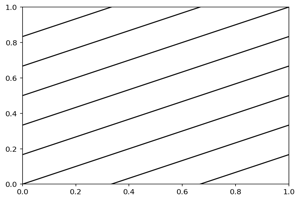

```python
"""
==============
Infinite lines
==============

`~.axes.Axes.axvline` and `~.axes.Axes.axhline` draw infinite vertical /
horizontal lines, at given *x* / *y* positions. They are usually used to mark
special data values, e.g. in this example the center and limit values of the
sigmoid function.

`~.axes.Axes.axline` draws infinite straight lines in arbitrary directions.

.. redirect-from:: /galler...
```

### `csd_demo.png`

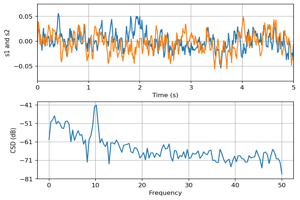

```python
"""
============================
Cross spectral density (CSD)
============================

Plot the cross spectral density (CSD) of two signals using `~.Axes.csd`.
"""
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(2, 1, layout='constrained')

dt = 0.01
t = np.arange(0, 30, dt)

# Fixing random state for reproducibility
np.random.seed(19680801)


nse1 = np.rand...
```

In [2]:
import json
import random
from PIL import Image
from IPython.display import display, Markdown

# Load dataset
data = [json.loads(l) for l in open("plot2code_exec.jsonl")]

print(f"Loaded {len(data)} samples")

# Show 5 random examples
for sample in random.sample(data, min(5, len(data))):
    display(Markdown(f"### `{Path(sample['image']).name}`"))
    display(Image.open(sample["image"]).resize((300, 200)))
    display(Markdown(f"```python\n{sample['code'][:400]}...\n```"))

## Step 5: Load Vision-Language Model

Load the Qwen2.5-VL model for zero-shot plot code generation.

In [4]:
import torch
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

# Model configuration
model_id = "Qwen/Qwen2.5-VL-7B-Instruct"
dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

# Load processor and model
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=dtype,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="sdpa",  # Important on CUDA 12.4
)

# Set pad_token_id to eos to avoid device-side asserts
eos_id = processor.tokenizer.eos_token_id
model.generation_config.eos_token_id = eos_id
model.generation_config.pad_token_id = eos_id

/home/nipun.batra/.uv/nb-base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 5/5 [00:02<00:00,  2.07it/s]


## Step 6: Define Code Generation Function

Create a function to generate matplotlib code from plot images.

In [5]:
from PIL import Image

def gen_code_for_image(img_path, max_new_tokens=512, temperature=0.0):
    """
    Generate matplotlib code from a plot image using the VLM.
    
    Args:
        img_path: Path to the input image
        max_new_tokens: Maximum number of tokens to generate
        temperature: Sampling temperature (0.0 for deterministic)
    
    Returns:
        Generated code as a string
    """
    img = Image.open(img_path).convert("RGB")

    # Construct the prompt message
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text",
             "text": ("You are a Matplotlib expert. "
                      "Write minimal runnable Python code to recreate this plot. "
                      "Use only matplotlib.pyplot (and numpy if needed). "
                      "Return ONLY a fenced Python code block.")
            },
        ],
    }]

    # Apply chat template to create string with special vision tokens
    convo = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    # Process text and image together
    inputs = processor(text=[convo], images=[img], return_tensors="pt").to(model.device, dtype)

    # Generate code
    with torch.inference_mode():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=False,
            use_cache=True,
        )
    return processor.batch_decode(out, skip_special_tokens=True)[0]

## Step 7: Test Code Generation

Test the code generation on a single example image.

In [6]:
# Demo on one image
print(gen_code_for_image("plot_gallery_exec/simple_plot.png"))

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


system
You are a helpful assistant.
user
You are a Matplotlib expert. Write minimal runnable Python code to recreate this plot. Use only matplotlib.pyplot (and numpy if needed). Return ONLY a fenced Python code block.
assistant
```python
import numpy as np
import matplotlib.pyplot as plt

# Generate data
t = np.linspace(0, 2, 400)
voltage = np.sin(2 * np.pi * t)

# Plot the data
plt.plot(t, voltage, label='Voltage (mV)')
plt.xlabel('time (s)')
plt.ylabel('voltage (mV)')
plt.title('About as simple as it gets, folks')
plt.legend()
plt.grid(True)
plt.show()
```


## Step 8: Define Evaluation Functions

Helper functions for extracting code, executing it, and computing similarity metrics.

In [16]:
import io, re, json, numpy as np, matplotlib, ast, textwrap
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from difflib import SequenceMatcher
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from IPython.display import display, Markdown

# ----------------------------------------
# Helper functions
# ----------------------------------------
def extract_code(text):
    """Extract fenced Python code from LLM output."""
    m = re.search(r"```(?:python)?\s*([\s\S]*?)```", text)
    return m.group(1).strip() if m else text.strip()

def render_code_to_png(py_code, out_path):
    """Safely execute Matplotlib code and save plot to PNG."""
    import builtins
    safe_builtins = {
        "range": range, "len": len, "print": print, "__import__": builtins.__import__,
    }
    safe_globals = {"__builtins__": safe_builtins, "np": __import__("numpy"), "plt": plt}
    plt.close("all")
    try:
        exec(py_code, safe_globals, None)
        if not plt.get_fignums():
            plt.figure()
        plt.savefig(out_path, bbox_inches="tight", dpi=150)
        plt.close("all")
        return True
    except Exception as e:
        print(f"⚠️ Execution failed: {e}")
        return False

def image_ssim(img_a, img_b):
    """Compute SSIM similarity between two images."""
    a = np.array(Image.open(img_a).convert("L"))
    b = np.array(Image.open(img_b).convert("L"))
    h, w = min(a.shape[0], b.shape[0]), min(a.shape[1], b.shape[1])
    a, b = a[:h, :w], b[:h, :w]
    return float(ssim(a, b))

def extract_calls(py_code):
    """Return list of Matplotlib function calls used in code."""
    try:
        tree = ast.parse(py_code)
    except Exception:
        return []
    calls = []
    for node in ast.walk(tree):
        if isinstance(node, ast.Call) and isinstance(node.func, ast.Attribute):
            calls.append(node.func.attr)
    return calls

def code_bleu(ref, gen):
    """Compute smoothed BLEU for short code snippets."""
    smoothie = SmoothingFunction().method1
    return sentence_bleu([ref.split()], gen.split(), smoothing_function=smoothie)

def code_edit_sim(ref, gen):
    """Edit-distance-based code similarity."""
    return SequenceMatcher(None, ref, gen).ratio()

def api_overlap_verbose(ref_code, gen_code):
    """Compute API overlap + show matched/missed calls."""
    ref_calls, gen_calls = set(extract_calls(ref_code)), set(extract_calls(gen_code))
    matched = ref_calls & gen_calls
    missed = ref_calls - gen_calls
    extras = gen_calls - ref_calls
    sim = len(matched) / len(ref_calls) if ref_calls else 0.0
    return sim, matched, missed, extras

# ----------------------------------------
# Unified verbose evaluator
# ----------------------------------------
def evaluate_plot2code_verbose(img_path, ref_code):
    print(f"\n🖼️ Evaluating: {img_path}")
    print("=" * 80)

    # --- Generate ---
    result_text = gen_code_for_image(img_path)
    code = extract_code(result_text)

    # --- Show generated code (truncated) ---
    print("\n🧠 Model Output (first 20 lines):")
    print("-" * 80)
    print("\n".join(code.splitlines()[:20]))
    print("-" * 80)

    # --- Execute and render ---
    gen_path = "recreated.png"
    ok = render_code_to_png(code, gen_path)
    if not ok:
        print("❌ Code execution failed.")
        return

    # --- Compute metrics ---
    ssim_score = image_ssim(img_path, gen_path)
    bleu = code_bleu(ref_code, code)
    edit_sim = code_edit_sim(ref_code, code)
    api_sim, matched, missed, extras = api_overlap_verbose(ref_code, code)

    # --- Log API details ---
    print("\n🔧 API Usage Analysis")
    print("-" * 80)
    print(f"Reference APIs ({len(matched)+len(missed)}): {sorted(extract_calls(ref_code))}")
    print(f"Generated APIs ({len(matched)+len(extras)}): {sorted(extract_calls(code))}")
    print(f"✅ Matched: {sorted(matched)}")
    print(f"❌ Missed (in ref but not gen): {sorted(missed)}")
    print(f"➕ Extra (in gen but not ref): {sorted(extras)}")

    # --- Combine metrics ---
    code_score = 0.4*bleu + 0.3*edit_sim + 0.3*api_sim
    overall = 0.5*ssim_score + 0.5*code_score

    print("\n📊 Quantitative Scores")
    print("-" * 80)
    print(f"SSIM (Visual):       {ssim_score:.3f}")
    print(f"BLEU (Text):         {bleu:.3f}")
    print(f"Edit Similarity:     {edit_sim:.3f}")
    print(f"API Overlap:         {api_sim:.3f}")
    print(f"Composite CodeScore: {code_score:.3f}")
    print(f"Overall Score:       {overall:.3f}")
    print("=" * 80)

    # --- Display visual comparison ---
    ref_img = Image.open(img_path).resize((400, 300))
    gen_img = Image.open(gen_path).resize((400, 300))
    side = Image.new("RGB", (800, 300))
    side.paste(ref_img, (0, 0))
    side.paste(gen_img, (400, 0))

    display(Markdown(f"### 🧩 Evaluation Summary: `{Path(img_path).name}`"))
    display(Markdown(f"""
**Visual:** SSIM `{ssim_score:.3f}`  
**Code:** BLEU `{bleu:.3f}` · Edit `{edit_sim:.3f}` · API `{api_sim:.3f}`  
**API Details:** ✅ `{matched}` · ❌ `{missed}` · ➕ `{extras}`  
**Aggregate:** CodeScore `{code_score:.3f}` · Overall `{overall:.3f}`
"""))
    display(side)


## Step 9: Run Evaluation

Evaluate the model on a sample plot.


🖼️ Evaluating plot_gallery_exec/simple_plot.png ...

🧠 Model output (truncated):
 import numpy as np
import matplotlib.pyplot as plt

# Generate data
t = np.linspace(0, 2, 400)
voltage = np.sin(2 * np.pi * t)

# Plot the data
plt.plot(t, voltage, label='Voltage (mV)')
plt.xlabel('time (s)')
plt.ylabel('voltage (mV)')
plt.title('About as simple as it gets, folks')
plt.legend()
plt.grid(True)
plt.show() 
...


### plot_gallery_exec/simple_plot.png


**Visual:** SSIM `0.732`  
**Code:** BLEU `0.021` · Edit `0.008` · API `0.333`  
**Aggregate:** CodeScore `0.111` · Overall `0.421`


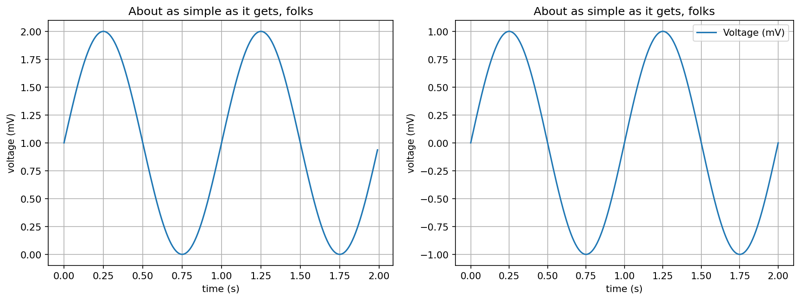

In [17]:
# load reference code from your dataset
with open("plot2code_exec.jsonl") as f:
    ref_data = json.loads(next(f))
ref_code = ref_data["code"]

evaluate_plot2code_full("plot_gallery_exec/simple_plot.png", ref_code)

## TODO List

Future improvements and tasks:

1. Clean up notebook - if dataset exists, skip generation steps
2. Remove Unicode characters
3. Run in batch mode over all images
4. Report SSIM scores
5. Decouple data generation and model training notebooks
6. Decouple evaluation and zero-shot code gen
7. Add additional metrics - exec@1
8. Fine-tune model on this data
9. Keep a clean test set separate from training data
10. On test set evaluate zero shot and fine-tuned model